In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

In [ ]:
µnp.random.seed(46)

In [ ]:
data={
    'CustomerID': range(1,101),
    'Age': np.random.randint(18, 70, size=100),
    'Gender': np.random.choice(['Male', 'Female'], size = 100),
    'Country': np.random.choice(['USA','CANADA','Tunisia', 'France', 'Germany', 'UK'], size = 100),
    'ProductCategory': np.random.choice(['Electronics','Clothings','Home','Beauty','Books'],size=100),
    'PurchaseAmmount': np.round(np.random.uniform(5,500, size=100),2),
    'Rating': np.random.choice([1,2,3,4,5,np.nan],size=100),
    'Review': np.random.choice(["Poor","Bad","Average","Good","Excellent"],size=100),
    'PurshaseDate': pd.Series(pd.date_range(start="2022-01-01", periods=100, freq = 'D').append(pd.date_range(start="2010-01-01", periods=10, freq = 'D'))).sample(100).reset_index(drop=True),
    'LoyaltyMembers': np.random.choice(['Yes','No'], size=100),
    'Returned': np.random.choice(['Yes','No'], size=100)
}

In [ ]:
df = pd.DataFrame(data)


In [ ]:
df.head(20)

,CustomerID,Age,Gender,Country,ProductCategory,PurchaseAmmount,Rating,Review,PurshaseDate,LoyaltyMembers,Returned
0,1,66.0,Female,USA,Books,96.32,5.0,Poor,2022-01-09,Yes,Yes
1,2,37.0,Female,Tunisia,Books,133.67,2.0,Good,2022-03-07,No,No
2,3,20.0,Female,USA,Electronics,498.59,NaN,Excellent,2022-02-02,No,Yes
3,4,34.0,Female,France,Beauty,465.43,5.0,Good,2022-02-16,Yes,Yes
4,5,48.0,Male,UK,Home,173.69,5.0,Excellent,2022-01-13,Yes,Yes
5,6,57.0,Male,France,Electronics,222.30,NaN,Bad,2022-01-31,No,No
6,7,30.0,Male,Tunisia,Home,134.50,NaN,Average,2022-04-02,Yes,No
7,8,NaN,Female,UK,Electronics,378.92,5.0,Good,2022-02-14,No,Yes
8,9,63.0,Male,France,Home,290.86,2.0,Poor,2022-03-25,No,No
9,10,30.0,Female,USA,Beauty,338.11,1.0,Poor,2022-04-09,Yes,No


In [ ]:
#adding some misssing values
for col in ['Age', 'Rating']:
  df.loc[df.sample(frac=0.1).index,col] =np.nan

In [ ]:
#adding some outliers in PurchaseAmmount
df.loc[df.sample(frac=0.05).index, 'PurchaseAmmount'] = df['PurchaseAmmount']*10

In [ ]:
df.isna().sum()

,0
CustomerID,0
Age,10
Gender,0
Country,0
ProductCategory,0
PurchaseAmmount,0
Rating,27
Review,0
PurshaseDate,0
LoyaltyMembers,0


In [ ]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Rating'].fillna(df['Rating'].mode()[0],inplace=True)

In [ ]:
df.isna().sum()

,0
CustomerID,0
Age,0
Gender,0
Country,0
ProductCategory,0
PurchaseAmmount,0
Rating,0
Review,0
PurshaseDate,0
LoyaltyMembers,0


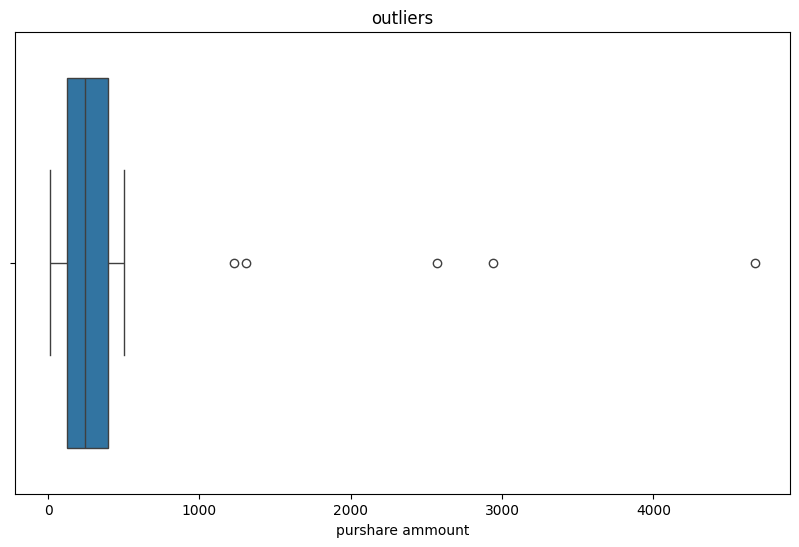

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['PurchaseAmmount'])
plt.title("outliers")
plt.xlabel("purshare ammount")
plt.show()

In [ ]:
Q1 = df['PurchaseAmmount'].quantile(0.25)
Q3 = df['PurchaseAmmount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1-1.5* IQR
upper_bound = Q3 + 1.5 * IQR

In [ ]:
df["PurchaseAmmount"] = np.where(df["PurchaseAmmount"] > upper_bound,upper_bound, df["PurchaseAmmount"])

In [ ]:
df.tail(20)

,CustomerID,Age,Gender,PurchaseAmmount,Rating,Review,PurshaseDate,LoyaltyMembers,Returned,Country_CANADA,Country_France,Country_Germany,Country_Tunisia,Country_UK,Country_USA,ProductCategory_Beauty,ProductCategory_Books,ProductCategory_Clothings,ProductCategory_Electronics,ProductCategory_Home
80,81,18.0,0,347.75000,4.0,4,2022-02-18,1,0,False,False,False,False,True,False,False,False,False,True,False
81,82,25.0,1,110.43000,4.0,2,2022-02-06,1,1,False,False,False,True,False,False,False,False,True,False,False
82,83,26.0,1,493.24000,4.0,3,2022-02-25,1,1,True,False,False,False,False,False,False,False,False,True,False
83,84,66.0,0,245.06000,3.0,5,2022-02-23,1,0,False,True,False,False,False,False,False,False,False,True,False
84,85,53.0,0,26.75000,1.0,5,2022-02-24,0,0,True,False,False,False,False,False,False,True,False,False,False
85,86,66.0,1,801.19625,4.0,2,2022-02-26,1,1,True,False,False,False,False,False,True,False,False,False,False
86,87,31.0,0,801.19625,5.0,4,2022-03-13,1,0,False,False,False,False,True,False,True,False,False,False,False
87,88,44.0,0,58.24000,4.0,4,2022-01-19,1,1,False,False,False,False,True,False,False,False,False,False,True
88,89,53.0,0,347.61000,4.0,1,2022-03-26,0,0,False,False,False,False,False,True,False,False,True,False,False
89,90,26.0,0,173.43000,5.0,4,2022-03-03,0,0,False,False,False,True,False,False,False,True,False,False,False


In [ ]:
df.describe()

,CustomerID,Age,PurchaseAmmount,Rating,PurshaseDate
count,100.000000,100.000000,100.000000,100.000000,100
mean,50.500000,43.340000,274.095012,3.400000,2021-01-16 08:24:00
min,1.000000,18.000000,12.840000,1.000000,2010-01-01 00:00:00
25%,25.750000,33.750000,127.552500,2.750000,2022-01-17 18:00:00
50%,50.500000,43.000000,246.385000,4.000000,2022-02-13 12:00:00
75%,75.250000,53.000000,397.010000,4.000000,2022-03-12 06:00:00
max,100.000000,69.000000,801.196250,5.000000,2022-04-10 00:00:00
std,29.011492,14.195048,187.378126,1.318095,NaN


In [ ]:
start_date = pd.Timestamp('2022-01-01')
end_date = pd.Timestamp('2024-01-01')

df['PurshaseDate'] = df['PurshaseDate'].apply(lambda x: x if start_date<= x <= end_date else np.nan)

In [ ]:
median_date = df['PurshaseDate'].median()

In [ ]:
df['PurshaseDate'].fillna(median_date, inplace=True)

In [ ]:
review_mapping={
    "Poor":1,
    "Bad":2,
    "Average":3,
    "Good":4,
    "Excellent":5
}

In [ ]:
df["Review"] = df["Review"].map(review_mapping)

In [ ]:
label_enc = LabelEncoder()

In [ ]:
df["Gender"] = label_enc.fit_transform(df["Gender"])
df["LoyaltyMembers"] = label_enc.fit_transform(df["LoyaltyMembers"])
df["Returned"] = label_enc.fit_transform(df["Returned"])

In [ ]:
df = pd.get_dummies(df, columns=['Country','ProductCategory'])

In [ ]:
df['PurshaseMonth'] = df['PurshaseDate'].dt.month
df['PurshaseYear'] = df['PurshaseDate'].dt.year

In [ ]:
df.drop(columns=['PurshaseDate'],inplace=True)

In [ ]:
scaler = StandardScaler()

In [ ]:
df["PurchaseAmmount"] = scaler.fit_transform(df[["PurchaseAmmount"]])

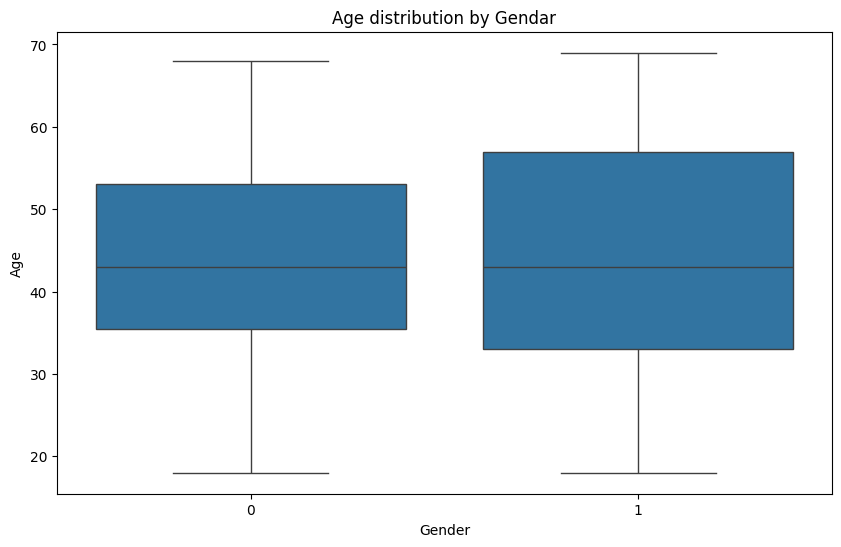

In [ ]:
plt.figure(figsize = (10,6))
sns.boxplot(x='Gender', y='Age', data=df)
plt.title('Age distribution by Gendar')
plt.show()

In [ ]:
X=df.drop(columns=["Returned"])
y=df["Returned"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.6

In [ ]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.69      0.69      0.69        13\n           1       0.43      0.43      0.43         7\n\n    accuracy                           0.60        20\n   macro avg       0.56      0.56      0.56        20\nweighted avg       0.60      0.60      0.60        20\n'